In [1]:
import numpy as np
import pandas as pd
import os
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
import torchvision.models as models
from torchvision.models import ResNet50_Weights
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from torchvision import transforms
import time
from tqdm import tqdm
import math
from sklearn.model_selection import train_test_split
import json

In [2]:
INPUT_PATH = Path('/kaggle/input/')
WORKING_PATH = Path('/kaggle/working/')

DATASET_PATH = INPUT_PATH / Path('celeba-10k-aligned/CelebA_10K_aligned')
IDENTITY_FILE_PATH = DATASET_PATH / Path('identity_CelebA.txt')
IMAGE_DIR_PATH = DATASET_PATH / Path('images')

SPLIT_METADATA_PATH = WORKING_PATH / Path('celeba_split_metadata.csv')
FULL_SPLIT_METADATA_PATH = WORKING_PATH / Path('celeba_full_split_metadata.csv')

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

RANDOM_SEED = 42

In [3]:
identity_df = pd.read_csv(IDENTITY_FILE_PATH, sep=' ', header=None, names=['image_id', 'identity_id'])

identity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10013 entries, 0 to 10012
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   image_id     10013 non-null  object
 1   identity_id  10013 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 156.6+ KB


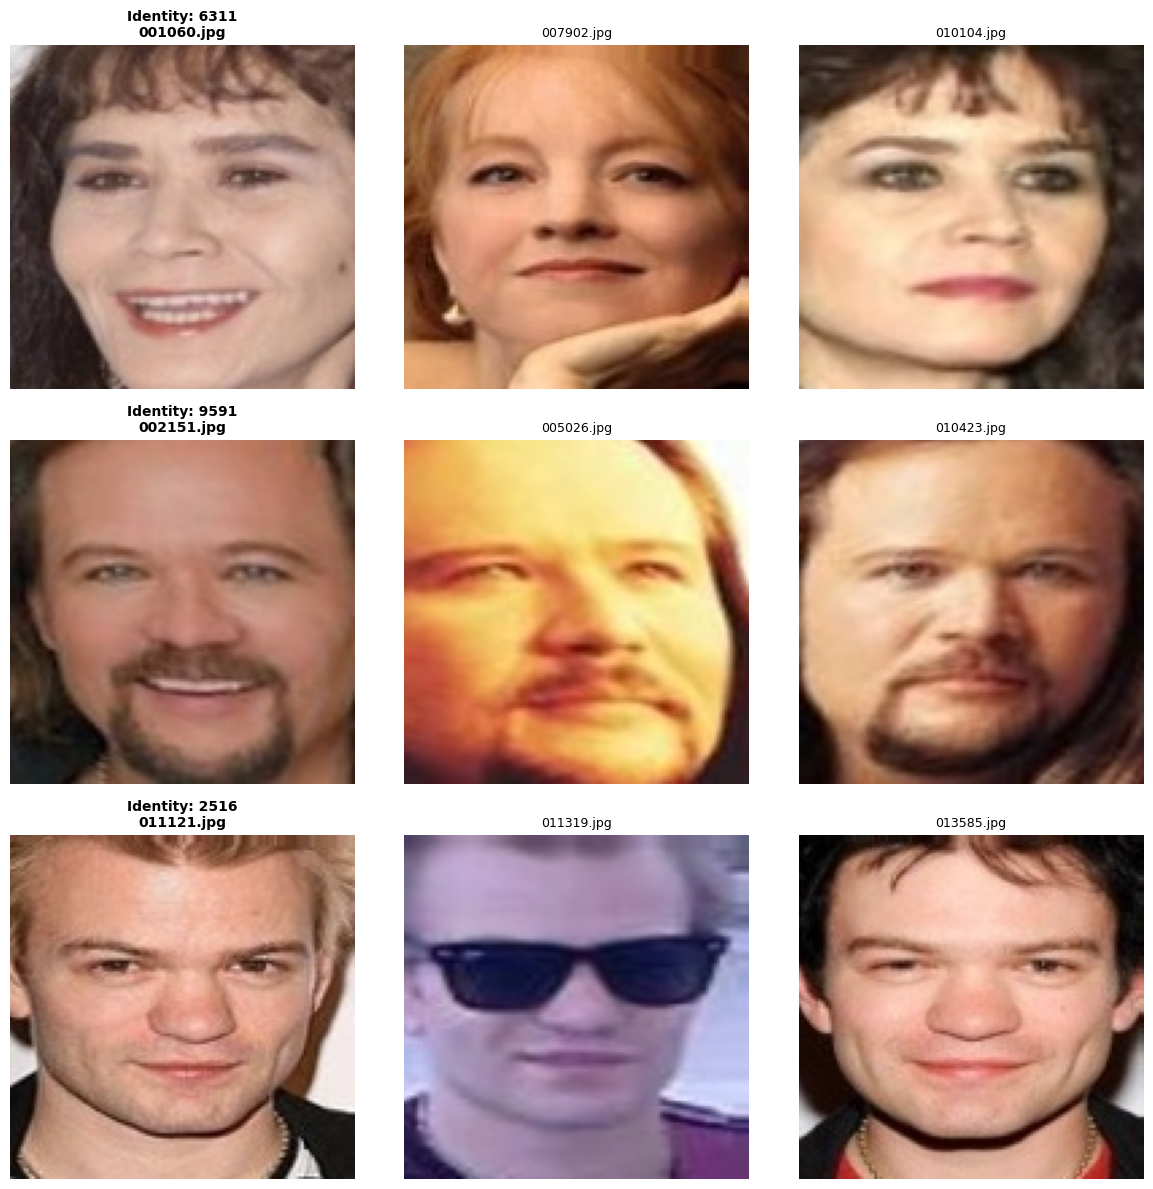

In [4]:
identity_counts = identity_df['identity_id'].value_counts()
identities_with_3plus = identity_counts[identity_counts >= 3].index.tolist()

random.seed(RANDOM_SEED)
selected_identities = random.sample(identities_with_3plus, min(3, len(identities_with_3plus)))

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row_idx, identity_id in enumerate(selected_identities):
    identity_images = identity_df[identity_df['identity_id'] == identity_id]['image_id'].tolist()

    selected_images = identity_images[:3]
    
    for col_idx, img_name in enumerate(selected_images):
        img_path = IMAGE_DIR_PATH / img_name
        
        if img_path.exists():
            img = Image.open(img_path)
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].axis('off')

            if col_idx == 0:
                axes[row_idx, col_idx].set_title(
                    f'Identity: {identity_id}\n{img_name}', 
                    fontsize=10, 
                    fontweight='bold'
                )
            else:
                axes[row_idx, col_idx].set_title(img_name, fontsize=9)
        else:
            axes[row_idx, col_idx].text(
                0.5, 0.5, 
                'Image not found', 
                ha='center', 
                va='center'
            )
            axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.show()

```
ДАТАСЕТ
├── TRAIN (70%)              - Для обучения модели
├── VAL (15%)                - Мониторинг во время обучения
│   ├── Val Query (30%)      - Запросы для IR
│   └── Val Gallery (70%)    - База для поиска
└── TEST (15%)               - Финальная оценка
    ├── Test Query (30%)     
    └── Test Gallery (70%)

```

In [5]:
def create_train_val_test_split_celeba(
    identity_df,
    output_csv=SPLIT_METADATA_PATH,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    min_images_per_identity=10,
    random_seed=42
):
    """
    ИСПРАВЛЕННАЯ версия: разделяет ИЗОБРАЖЕНИЯ, сохраняя всех людей во всех splits
    
    Для каждого человека:
    - 70% его фото → train
    - 15% его фото → val
    - 15% его фото → test
    
    Все люди присутствуют во всех splits!
    """
    df = identity_df.copy()
    if 'image_id' in df.columns:
        df = df.rename(columns={'image_id': 'filename'})
    
    df['full_path'] = df['filename'].apply(
        lambda x: os.path.join(IMAGE_DIR_PATH, x)
    )
    
    # Фильтрация по минимальному количеству
    print(f"\nФильтрация людей с < {min_images_per_identity} изображениями...")
    identity_counts = df['identity_id'].value_counts()
    valid_identities = identity_counts[identity_counts >= min_images_per_identity].index
    df = df[df['identity_id'].isin(valid_identities)].reset_index(drop=True)
    
    print(f"  После фильтрации: {len(df)} изображений, {df['identity_id'].nunique()} людей")
    
    # Разделяем ИЗОБРАЖЕНИЯ КАЖДОГО человека
    train_data = []
    val_data = []
    test_data = []
    
    for identity in df['identity_id'].unique():
        # Все изображения этого человека
        person_df = df[df['identity_id'] == identity]
        
        num_images = len(person_df)
        
        # Вычисляем размеры splits для этого человека
        num_train = max(1, int(num_images * train_ratio))
        num_val = max(1, int(num_images * val_ratio))
        num_test = num_images - num_train - num_val
        
        # Если test получился 0, перераспределяем
        if num_test == 0 and num_images >= 3:
            num_train -= 1
            num_test = 1
        
        # Перемешиваем и разделяем
        person_df_shuffled = person_df.sample(frac=1, random_state=random_seed).reset_index(drop=True)
        
        train_part = person_df_shuffled.iloc[:num_train]
        val_part = person_df_shuffled.iloc[num_train:num_train+num_val]
        test_part = person_df_shuffled.iloc[num_train+num_val:]
        
        train_data.append(train_part)
        val_data.append(val_part)
        if len(test_part) > 0:
            test_data.append(test_part)
    
    # Объединяем
    train_df = pd.concat(train_data).reset_index(drop=True)
    val_df = pd.concat(val_data).reset_index(drop=True)
    test_df = pd.concat(test_data).reset_index(drop=True) if test_data else pd.DataFrame()
    
    train_df['split'] = 'train'
    val_df['split'] = 'val'
    if len(test_df) > 0:
        test_df['split'] = 'test'
    
    # Объединяем все
    final_df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)
    
    # Статистика
    print("РЕЗУЛЬТАТЫ SPLIT")
    
    for split in ['train', 'val', 'test']:
        split_df = final_df[final_df['split'] == split]
        if len(split_df) == 0:
            continue
        
        print(f"\n{split.upper()}:")
        print(f"  Изображений: {len(split_df)} ({len(split_df)/len(final_df)*100:.1f}%)")
        print(f"  Уникальных людей: {split_df['identity_id'].nunique()}")
        print(f"  Среднее изображений/человек: {len(split_df)/split_df['identity_id'].nunique():.2f}")

    print("ПРОВЕРКА ПЕРЕКРЫТИЯ")
    
    train_ids = set(train_df['identity_id'].unique())
    val_ids = set(val_df['identity_id'].unique())
    test_ids = set(test_df['identity_id'].unique()) if len(test_df) > 0 else set()
    
    train_val_overlap = train_ids & val_ids
    train_test_overlap = train_ids & test_ids
    
    print(f"Train ∩ Val: {len(train_val_overlap)} людей")
    print(f"Train ∩ Test: {len(train_test_overlap)} людей")
    
    if len(train_val_overlap) == len(train_ids) == len(val_ids):
        print("✅ ОТЛИЧНО! Все люди присутствуют в train И val")
    else:
        print("⚠️  Не все люди во всех splits")
    
    # Сохраняем
    final_df.to_csv(output_csv, index=False)
    print(f"\n✓ Метаданные сохранены: {output_csv}")
    print("="*70)
    
    return final_df

In [6]:
def create_query_gallery_for_split_celeba(df, split_name, query_ratio=0.3, random_seed=RANDOM_SEED):
    """    
    Args:
        df: DataFrame с метаданными разделёнными на train/val/test
        split_name: 'val' или 'test'
        query_ratio: Доля для query (обычно 0.2-0.3)
        random_seed: Seed
    
    Returns:
        query_df, gallery_df
    """
    
    split_df = df[df['split'] == split_name].copy()
    
    query_data = []
    gallery_data = []
    
    print(f"Creating Query/Gallery split for {split_name.upper()}...")

    for identity in split_df['identity_id'].unique():
        identity_df = split_df[split_df['identity_id'] == identity]
        
        num_images = len(identity_df)

        num_query = max(1, int(num_images * query_ratio))

        query_indices = identity_df.sample(n=num_query, random_state=random_seed).index

        query_df_identity = identity_df.loc[query_indices]
        gallery_df_identity = identity_df.drop(query_indices)

        query_data.append(query_df_identity)

        if len(gallery_df_identity) > 0:
            gallery_data.append(gallery_df_identity)

    query_df = pd.concat(query_data).reset_index(drop=True)
    gallery_df = pd.concat(gallery_data).reset_index(drop=True)

    query_df['subset'] = 'query'
    gallery_df['subset'] = 'gallery'
    
    print(f"  Query: {len(query_df)} images from {query_df['identity_id'].nunique()} identities")
    print(f"  Gallery: {len(gallery_df)} images from {gallery_df['identity_id'].nunique()} identities")
    
    return query_df, gallery_df


def create_full_split_with_query_gallery_celeba(
    identity_df,
    output_csv=FULL_SPLIT_METADATA_PATH,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    query_ratio=0.3,
    min_images_per_identity=10,
    random_seed=RANDOM_SEED
):  
    df = create_train_val_test_split_celeba(
        identity_df=identity_df,
        train_ratio=train_ratio,
        val_ratio=val_ratio,
        test_ratio=test_ratio,
        min_images_per_identity=min_images_per_identity,
        random_seed=random_seed
    )

    val_query_df, val_gallery_df = create_query_gallery_for_split_celeba(
        df, 'val', query_ratio, random_seed
    )

    test_query_df, test_gallery_df = create_query_gallery_for_split_celeba(
        df, 'test', query_ratio, random_seed
    )

    train_df = df[df['split'] == 'train'].copy()
    train_df['subset'] = 'train'
    
    # Объединяем все
    full_df = pd.concat([
        train_df,
        val_query_df,
        val_gallery_df,
        test_query_df,
        test_gallery_df
    ]).reset_index(drop=True)
    
    # Сохраняем
    full_df.to_csv(output_csv, index=False)
    
    print(f"Full metadata with Query/Gallery saved to: {output_csv}")

    print("FINAL DATASET STATISTICS")
    
    print("\nTRAIN:")
    print(f"  Images: {len(train_df)}")
    print(f"  Identities: {train_df['identity_id'].nunique()}")
    
    print("\nVAL:")
    print(f"  Total: {len(val_query_df) + len(val_gallery_df)} images")
    print(f"  Query: {len(val_query_df)} images ({val_query_df['identity_id'].nunique()} identities)")
    print(f"  Gallery: {len(val_gallery_df)} images ({val_gallery_df['identity_id'].nunique()} identities)")
    
    print("\nTEST:")
    print(f"  Total: {len(test_query_df) + len(test_gallery_df)} images")
    print(f"  Query: {len(test_query_df)} images ({test_query_df['identity_id'].nunique()} identities)")
    print(f"  Gallery: {len(test_gallery_df)} images ({test_gallery_df['identity_id'].nunique()} identities)")
    
    return full_df

In [7]:
split_metadata_df = create_full_split_with_query_gallery_celeba(
    identity_df=identity_df,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    query_ratio=0.3,
    min_images_per_identity=10,
    random_seed=RANDOM_SEED
)


Фильтрация людей с < 10 изображениями...
  После фильтрации: 10013 изображений, 409 людей
РЕЗУЛЬТАТЫ SPLIT

TRAIN:
  Изображений: 6824 (68.2%)
  Уникальных людей: 409
  Среднее изображений/человек: 16.68

VAL:
  Изображений: 1327 (13.3%)
  Уникальных людей: 409
  Среднее изображений/человек: 3.24

TEST:
  Изображений: 1862 (18.6%)
  Уникальных людей: 409
  Среднее изображений/человек: 4.55
ПРОВЕРКА ПЕРЕКРЫТИЯ
Train ∩ Val: 409 людей
Train ∩ Test: 409 людей
✅ ОТЛИЧНО! Все люди присутствуют в train И val

✓ Метаданные сохранены: /kaggle/working/celeba_split_metadata.csv
Creating Query/Gallery split for VAL...
  Query: 409 images from 409 identities
  Gallery: 918 images from 409 identities
Creating Query/Gallery split for TEST...
  Query: 409 images from 409 identities
  Gallery: 1453 images from 409 identities
Full metadata with Query/Gallery saved to: /kaggle/working/celeba_full_split_metadata.csv
FINAL DATASET STATISTICS

TRAIN:
  Images: 6824
  Identities: 409

VAL:
  Total: 1327 ima

In [8]:
class CelebAFaceRecognitionDataset(Dataset):   
    def __init__(self, 
                 metadata_csv,
                 split='train',
                 subset=None,
                 transform=None):
        """
        Args:
            metadata_csv: CSV файл с метаданными
            split: 'train', 'val', или 'test'
            subset: None (весь split), 'query', или 'gallery'
            transform: Трансформации
        """
        # Загружаем метаданные
        df = pd.read_csv(metadata_csv)
        
        # Фильтруем по split
        df = df[df['split'] == split]
        
        # Фильтруем по subset если указан
        if subset is not None:
            if 'subset' not in df.columns:
                raise ValueError(f"Subset column not found. Use metadata file with query/gallery splits.")
            df = df[df['subset'] == subset]
        
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
        # Создаем маппинг identity_id -> label
        full_df = pd.read_csv(metadata_csv)
        unique_identities = sorted(full_df['identity_id'].unique())
        self.id_to_label = {id_: idx for idx, id_ in enumerate(unique_identities)}
        
        self.num_classes = len(unique_identities)
        
        # Для текущего split
        current_identities = self.df['identity_id'].nunique()
        
        subset_str = f" ({subset})" if subset else ""
        print(f"✓ {split.upper()}{subset_str} dataset loaded:")
        print(f"  Images: {len(self.df)}")
        print(f"  Identities in this split: {current_identities}")
        print(f"  Total identities (all splits): {self.num_classes}")
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = row['full_path']
        
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = self.id_to_label[row['identity_id']]
        
        return image, label


In [9]:
train_transforms = transforms.Compose([
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
    ], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(
        p=0.3,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3),
        value='random'
    ),
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = CelebAFaceRecognitionDataset(
    metadata_csv=FULL_SPLIT_METADATA_PATH,
    split='train',
    transform=train_transforms
)

val_dataset = CelebAFaceRecognitionDataset(
    metadata_csv=FULL_SPLIT_METADATA_PATH,
    split='val',
    transform=val_transforms
)

test_dataset = CelebAFaceRecognitionDataset(
    metadata_csv=FULL_SPLIT_METADATA_PATH,
    split='test',
    transform=val_transforms
)

✓ TRAIN dataset loaded:
  Images: 6824
  Identities in this split: 409
  Total identities (all splits): 409
✓ VAL dataset loaded:
  Images: 1327
  Identities in this split: 409
  Total identities (all splits): 409
✓ TEST dataset loaded:
  Images: 1862
  Identities in this split: 409
  Total identities (all splits): 409


In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [43]:
class ArcFaceLoss(nn.Module):
    def __init__(self, num_classes, embedding_size=512, s=30.0, m=0.50):
        """
        Args:
            num_classes: Количество уникальных людей в датасете
            embedding_size: Размерность эмбеддинга (512)
            s: Scale parameter (30.0 - 64.0)
            m: Angular margin в радианах (0.5 ≈ 28.6°)
        """
        super(ArcFaceLoss, self).__init__()
        
        self.num_classes = num_classes
        self.embedding_size = embedding_size
        self.s = s
        self.m = m
        
        # Весовая матрица классификации (num_classes x embedding_size)
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_size))
        nn.init.xavier_uniform_(self.weight)
        
        # Предвычисленные константы для оптимизации
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.threshold = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m
    
    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: (batch_size, embedding_size) - из backbone
            labels: (batch_size,) - ground truth метки
            
        Returns:
            loss: scalar ArcFace loss
        """
        # Нормализация эмбеддингов, приводим все векторы к единичной длине
        embeddings = F.normalize(embeddings, p=2, dim=1)

        # Нормализация весов классов
        weight_norm = F.normalize(self.weight, p=2, dim=1)

        # Вычисление cos(θ) через скалярное произведение: cos = embeddings · weight^T
        cos = F.linear(embeddings, weight_norm)

        # Вычисление sin(θ) из cos(θ) через тождество: sin²(θ) + cos²(θ) = 1
        sin = torch.sqrt(1.0 - torch.pow(cos, 2))

        # Вычисление cos(θ + m) через тождество: cos(θ + m) = cos(θ)·cos(m) - sin(θ)·sin(m)
        phi = cos * self.cos_m - sin * self.sin_m

        # Если θ + m > π, используем cos(θ) - mm
        phi = torch.where(cos > self.threshold, phi, cos - self.mm)

        # Создание one-hot вектора для целевого класса
        one_hot = torch.zeros_like(cos)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)

        # Применение margin только к целевому классу
        output = (one_hot * phi) + ((1.0 - one_hot) * cos)

        # Масштабирование scale параметром s
        output *= self.s

        return F.cross_entropy(output, labels)

    def get_logits(self, embeddings):
        embeddings = F.normalize(embeddings, dim=1)
        weight_norm = F.normalize(self.weight, dim=1)

        return self.s * F.linear(embeddings, weight_norm)


In [49]:
class FaceRecognitionModel(nn.Module):
    def __init__(self, num_classes, embedding_size=512, loss_type='arcface', freeze_first_n_layers=0):
        """
        Args:
            num_classes: Количество уникальных людей
            embedding_size: Размерность эмбеддинга
            loss_type: 'arcface' или 'ce' (CrossEntropy)
        """
        super(FaceRecognitionModel, self).__init__()
        
        self.loss_type = loss_type
        
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        self.backbone = models.efficientnet_b0(weights=weights)

        self.backbone.classifier = nn.Identity()
        backbone_output_size = 1280

        if freeze_first_n_layers > 0:
            for i, block in enumerate(self.backbone.features):
                if i < freeze_first_n_layers:
                    for param in block.parameters():
                        param.requires_grad = False
        
        # Bottleneck для получения эмбеддингов
        self.bottleneck = nn.Sequential(
            nn.Linear(backbone_output_size, 512),
            nn.BatchNorm1d(512),
        )        
        # Loss layer в зависимости от типа
        if loss_type == 'arcface':
            self.loss_fn = ArcFaceLoss(
                num_classes=num_classes,
                embedding_size=embedding_size,
                s=64.0,
                m=0.50
            )
        elif loss_type == 'ce':
            # Для CrossEntropy нужен обычный FC layer
            self.classifier = nn.Linear(embedding_size, num_classes)
            self.loss_fn = nn.CrossEntropyLoss()
        else:
            raise ValueError(f"Unknown loss_type: {loss_type}")
        
        print(f"✓ FaceRecognitionModel initialized")
        print(f"  Loss type: {loss_type}")
    
    # def forward(self, images, labels=None):
    #     # Извлекаем features из backbone
    #     features = self.backbone(images)
        
    #     # Получаем эмбеддинги через bottleneck
    #     embeddings = self.bottleneck(features)
        
    #     # Если в режиме обучения и есть labels - вычисляем loss
    #     if self.training and labels is not None:
    #         if self.loss_type == 'arcface':
    #             loss = self.loss_fn(embeddings, labels)
    #         else:  # CrossEntropy
    #             logits = self.classifier(embeddings)
    #             loss = self.loss_fn(logits, labels)
            
    #         return embeddings, loss
    #     else:
    #         return embeddings

    def forward(self, images, labels=None):
        features = self.backbone(images)

        embeddings = self.bottleneck(features)
    
        logits = None

        if self.loss_type == 'ce':
            logits = self.classifier(embeddings)
        elif self.loss_type == 'arcface':
            logits = self.loss_fn.get_logits(embeddings)
            
        if self.training and labels is not None:
            if self.loss_type == 'ce':
                loss = self.loss_fn(logits, labels)
            else:
                loss = self.loss_fn(embeddings, labels)
    
            return embeddings, logits, loss
    
        return embeddings, logits

In [52]:
class FaceRecognitionTrainer:
    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        device='cuda',
        learning_rate=1e-4,
        num_epochs=30,
        checkpoint_dir='checkpoints',
        experiment_name='face_recognition'
    ):
        """
        Args:
            model: FaceRecognitionModel
            train_loader: DataLoader для обучения
            val_loader: DataLoader для валидации
            device: 'cuda' или 'cpu'
            learning_rate: Базовый learning rate
            num_epochs: Количество эпох
            checkpoint_dir: Папка для сохранения checkpoints
            experiment_name: Название эксперимента
        """
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.num_epochs = num_epochs
        
        # Создаем папку для эксперимента
        self.experiment_dir = os.path.join(checkpoint_dir, experiment_name)
        os.makedirs(self.experiment_dir, exist_ok=True)
        
        # Optimizer с разными learning rates для разных частей модели
        # self.optimizer = torch.optim.AdamW([
        #     {
        #         'params': model.backbone.parameters(), 
        #         'lr': 1e-5,
        #         'weight_decay': 1e-4
        #     },
        #     {
        #         'params': model.bottleneck.parameters(), 
        #         'lr': 3e-4,
        #         'weight_decay': 1e-4
        #     },
        # ])
        
        # Добавляем параметры loss layer
        if model.loss_type == 'arcface':
            self.optimizer = torch.optim.AdamW([
                {'params': model.backbone.parameters(), 'lr': 1e-4},
                {'params': model.bottleneck.parameters(), 'lr': 5e-4},
                {'params': model.loss_fn.parameters(), 'lr': 5e-4},
            ], weight_decay=5e-4)
        else:
            self.optimizer = torch.optim.AdamW(
                list(model.backbone.parameters()) +
                list(model.bottleneck.parameters()) +
                list(model.classifier.parameters()),
                lr=1e-4,
                weight_decay=1e-4
            )
            
            # self.optimizer.add_param_group({
            #     'params': model.classifier.parameters(), 
            #     'lr': learning_rate,
            #     'weight_decay': 1e-4
            # })

        # self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        #     self.optimizer, 
        #     T_max=num_epochs,
        #     eta_min=5e-5
        # )

        self.scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=10, gamma=0.1)
        
        # Mixed precision training
        if device == 'cuda':
            self.scaler = GradScaler('cuda')
            self.use_amp = True
        else:
            self.scaler = None
            self.use_amp = False
        
        self.history = {
            'train_loss': [],
            'train_top1': [],
            'train_top5': [],
            'train_top10': [],
            'val_loss': [],
            'val_top1': [],
            'val_top5': [],
            'val_top10': [],
            'val_rank1': [],
            'val_rank5': [],
            'val_rank10': [],
            'val_mAP': [],
            'lr': []
        }
        
        self.best_val_top1 = 0.0
        self.best_epoch = 0
    
    def train_one_epoch(self, epoch):
        self.model.train()
        
        total_loss = 0
        total_metrics = {'top1': 0, 'top5': 0, 'top10': 0}
        num_batches = 0
        
        pbar = tqdm(self.train_loader, desc=f'Epoch {epoch}/{self.num_epochs}')
        
        for images, labels in pbar:
            images = images.to(self.device)
            labels = labels.to(self.device)
            
            # Forward pass с mixed precision
            if self.use_amp:
                with autocast(device_type='cuda'):
                    embeddings, logits, loss = self.model(images, labels)
            else:
                embeddings, logits, loss = self.model(images, labels)
            
            # Compute accuracy
            with torch.no_grad():
                metrics = self.compute_accuracy(logits, labels)
                for k in metrics:
                    total_metrics[k] += metrics[k]
            
            # Backward pass
            self.optimizer.zero_grad()
            
            if self.use_amp:
                self.scaler.scale(loss).backward()                
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                loss.backward()
                self.optimizer.step()
            
            # Update metrics
            total_loss += loss.item()
            num_batches += 1

            current_lr = self.optimizer.param_groups[0]['lr']
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'top1': f'{metrics["top1"]:.4f}',
                'top5': f'{metrics["top5"]:.4f}',
                'lr': f'{current_lr:.6f}'
            })
        
        avg_metrics = {k: v / num_batches for k, v in total_metrics.items()}
        avg_metrics['loss'] = total_loss / num_batches
        
        return avg_metrics
    
    def val_one_epoch(self, compute_ir=False):
        """
        Args:
            compute_ir: Вычислять ли Identification Rate (медленнее)
        """
        self.model.eval()
        
        total_loss = 0
        total_metrics = {'top1': 0, 'top5': 0, 'top10': 0}
        num_batches = 0
        
        # Для IR метрик
        all_embeddings = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in tqdm(self.val_loader, desc='Validation'):
                images = images.to(self.device)
                labels = labels.to(self.device)
                
                # Forward pass
                if self.model.training:
                    self.model.eval()
                
                embeddings, logits = self.model(images)
                
                if self.model.loss_type == 'arcface':
                    loss = self.model.loss_fn(embeddings, labels)
                else:
                    loss = self.model.loss_fn(logits, labels)
                
                metrics = self.compute_accuracy(logits, labels)
                for k in metrics:
                    total_metrics[k] += metrics[k]
                
                total_loss += loss.item()
                num_batches += 1
                
                # Сохраняем для IR
                if compute_ir:
                    all_embeddings.append(
                        F.normalize(embeddings, dim=1).cpu().numpy()
                    )
                    all_labels.append(labels.cpu().numpy())
        
        avg_loss = total_loss / num_batches
        avg_metrics = {k: v / num_batches for k, v in total_metrics.items()}
        
        result_metrics = {
            'loss': avg_loss,
            'top1': avg_metrics['top1'],
            'top5': avg_metrics['top5'],
            'top10': avg_metrics['top10']
        }
        
        # Вычисляем IR если нужно
        if compute_ir and len(all_embeddings) > 0:
            embeddings = np.vstack(all_embeddings)
            labels = np.concatenate(all_labels)
            
            result_metrics.update(self.compute_identification_rate(embeddings, labels))
        
        return result_metrics

    def train(self, compute_ir_every=5):
        """
        Полный цикл обучения
        
        Args:
            compute_ir_every: Вычислять IR каждые N эпох
        """
        print("STARTING TRAINING")
        
        for epoch in range(1, self.num_epochs + 1):
            epoch_start_time = time.time()

            current_lr = self.optimizer.param_groups[0]['lr']
            self.history['lr'].append(current_lr)
            
            print(f"\nEpoch {epoch}/{self.num_epochs}")
            print(f"Learning Rate: {current_lr:.6f}")
            
            # Training
            train_metrics = self.train_one_epoch(epoch)
            
            # Validation
            compute_ir = (epoch % compute_ir_every == 0) or (epoch == self.num_epochs)
            val_metrics = self.val_one_epoch(compute_ir=compute_ir)
            
            self.history['train_loss'].append(train_metrics['loss'])
            self.history['train_top1'].append(train_metrics['top1'])
            self.history['train_top5'].append(train_metrics['top5'])
            self.history['train_top10'].append(train_metrics['top10'])
            
            self.history['val_loss'].append(val_metrics['loss'])
            self.history['val_top1'].append(val_metrics['top1'])
            self.history['val_top5'].append(val_metrics['top5'])
            self.history['val_top10'].append(val_metrics['top10'])
            
            if compute_ir:
                self.history['val_rank1'].append(val_metrics.get('rank1', 0))
                self.history['val_rank5'].append(val_metrics.get('rank5', 0))
                self.history['val_rank10'].append(val_metrics.get('rank10', 0))
                self.history['val_mAP'].append(val_metrics.get('mAP', 0))
            
            # Print summary
            epoch_time = time.time() - epoch_start_time
            
            print(f"\nEpoch {epoch} Summary:")
            print(f"  Train Loss: {train_metrics['loss']:.4f}")
            print(f"  Train Top-1: {train_metrics['top1']:.4f} | Top-5: {train_metrics['top5']:.4f} | Top-10: {train_metrics['top10']:.4f}")
            print(f"  Val Loss: {val_metrics['loss']:.4f}")
            print(f"  Val Top-1: {val_metrics['top1']:.4f} | Top-5: {val_metrics['top5']:.4f} | Top-10: {val_metrics['top10']:.4f}")
            
            if compute_ir:
                print(f"  Val Rank-1: {val_metrics['rank1']:.4f} | Rank-5: {val_metrics['rank5']:.4f} | Rank-10: {val_metrics['rank10']:.4f}")
                print(f"  Val mAP: {val_metrics['mAP']:.4f}")

            print(f"  Time: {epoch_time:.2f}s")
            
            # Save best model
            current_top1 = val_metrics['top1']
            if current_top1 > self.best_val_top1:
                self.best_val_top1 = current_top1
                self.best_epoch = epoch
                best_path = self.save_checkpoint(
                    epoch, val_metrics, 'best_model.pth'
                )
                print(f"  ★ New best model! Top-1: {self.best_val_top1:.4f}")

            self.scheduler.step()

        print("TRAINING COMPLETED")
        print(f"Best Epoch: {self.best_epoch}")
        print(f"Best Validation Top-1: {self.best_val_top1:.4f} ({self.best_val_top1*100:.2f}%)")
        
        self.save_checkpoint(self.num_epochs, val_metrics, 'final_model.pth')
        self.plot_history('final_history.png')
        
        # Save history as JSON
        history_path = os.path.join(self.experiment_dir, 'history.json')
        with open(history_path, 'w') as f:
            json.dump(self.history, f, indent=2)
        
        print(f"History saved: {history_path}")
    
    def compute_identification_rate(self, embeddings, labels):
        """
        Вычисляет Identification Rate (closed-set)
        Каждый образец используется как query, остальные как gallery
        """
        num_samples = len(labels)
        
        # Нормализуем эмбеддинги
        embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
        
        rank1_correct = 0
        rank5_correct = 0
        rank10_correct = 0
        
        average_precisions = []
        
        for i in range(num_samples):
            # Query
            query_emb = embeddings[i:i+1]
            query_label = labels[i]
            
            # Gallery (все кроме query)
            gallery_indices = np.concatenate([np.arange(i), np.arange(i+1, num_samples)])
            gallery_embs = embeddings[gallery_indices]
            gallery_labels = labels[gallery_indices]
            
            # Вычисляем сходства
            similarities = np.dot(query_emb, gallery_embs.T).squeeze()
            
            # Сортируем по убыванию сходства
            sorted_indices = np.argsort(-similarities)
            sorted_labels = gallery_labels[sorted_indices]
            
            # Проверяем ranks
            if sorted_labels[0] == query_label:
                rank1_correct += 1
            
            if query_label in sorted_labels[:5]:
                rank5_correct += 1
            
            if query_label in sorted_labels[:10]:
                rank10_correct += 1

            relevant_positions = np.where(sorted_labels == query_label)[0] + 1
            
            if len(relevant_positions) > 0:
                precisions = []
                for rank, pos in enumerate(relevant_positions, 1):
                    precision_at_pos = rank / pos
                    precisions.append(precision_at_pos)
                
                # Average Precision для этого query
                ap = np.mean(precisions)
                average_precisions.append(ap)
            else:
                average_precisions.append(0.0)
        
        return {
            'rank1': rank1_correct / num_samples,
            'rank5': rank5_correct / num_samples,
            'rank10': rank10_correct / num_samples,
            'mAP': np.mean(average_precisions)
        }

    def compute_accuracy(self, logits, labels):
        """
        Returns:
            dict с метриками: top1, top5, top10
        """
        # embeddings = embeddings.float()
        
        # if self.model.loss_type == 'arcface':
        #     embeddings_norm = F.normalize(embeddings, p=2, dim=1)
        #     weight_norm = F.normalize(self.model.loss_fn.weight, p=2, dim=1)
        #     logits = F.linear(embeddings_norm, weight_norm)
        # else:
        #     logits = self.model.classifier(embeddings)

        top1_acc = (logits.argmax(dim=1) == labels).float().mean().item()

        _, top5_predictions = torch.topk(logits, k=min(5, logits.size(1)), dim=1)
        top5_correct = 0
        for i, label in enumerate(labels):
            if label in top5_predictions[i]:
                top5_correct += 1
        top5_acc = top5_correct / labels.size(0)

        _, top10_predictions = torch.topk(logits, k=min(10, logits.size(1)), dim=1)
        top10_correct = 0
        for i, label in enumerate(labels):
            if label in top10_predictions[i]:
                top10_correct += 1
        top10_acc = top10_correct / labels.size(0)
        
        return {
            'top1': top1_acc,
            'top5': top5_acc,
            'top10': top10_acc
        }
        
    def save_checkpoint(self, epoch, metrics, filename):
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'metrics': metrics,
            'history': self.history,
            'loss_type': self.model.loss_type
        }
        
        filepath = os.path.join(self.experiment_dir, filename)
        torch.save(checkpoint, filepath)
        
        return filepath
    
    def plot_history(self, save_name='training_history.png'):
        """Визуализация с НОВЫМИ метриками"""
        has_ir = len(self.history['val_rank1']) > 0

        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()
        
        # 1. Loss
        axes[0].plot(self.history['train_loss'], label='Train', linewidth=2)
        axes[0].plot(self.history['val_loss'], label='Val', linewidth=2)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # 2. Top-1 Accuracy
        axes[1].plot(self.history['train_top1'], label='Train', linewidth=2)
        axes[1].plot(self.history['val_top1'], label='Val', linewidth=2)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Top-1 Accuracy')
        axes[1].set_title('Top-1 Accuracy')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # 3. Top-5 Accuracy
        axes[2].plot(self.history['train_top5'], label='Train', linewidth=2, color='green')
        axes[2].plot(self.history['val_top5'], label='Val', linewidth=2, color='lightgreen')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Top-5 Accuracy')
        axes[2].set_title('Top-5 Accuracy')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        # 4. Top-10 Accuracy
        axes[3].plot(self.history['train_top10'], label='Train', linewidth=2, color='purple')
        axes[3].plot(self.history['val_top10'], label='Val', linewidth=2, color='violet')
        axes[3].set_xlabel('Epoch')
        axes[3].set_ylabel('Top-10 Accuracy')
        axes[3].set_title('Top-10 Accuracy')
        axes[3].legend()
        axes[3].grid(True, alpha=0.3)
        
        # 5. Learning Rate
        axes[4].plot(self.history['lr'], linewidth=2, color='orange')
        axes[4].set_xlabel('Batch')
        axes[4].set_ylabel('Learning Rate')
        axes[4].set_title('Learning Rate')
        axes[4].set_yscale('log')
        axes[4].grid(True, alpha=0.3)
        
        # 6. IR метрики + mAP
        if has_ir:
            epochs_with_ir = [i*5 for i in range(len(self.history['val_rank1']))]
            axes[5].plot(epochs_with_ir, self.history['val_rank1'], 
                        label='Rank-1', linewidth=2, marker='o')
            axes[5].plot(epochs_with_ir, self.history['val_rank5'], 
                        label='Rank-5', linewidth=2, marker='s')
            axes[5].plot(epochs_with_ir, self.history['val_mAP'], 
                        label='mAP', linewidth=2, marker='^', color='red')
            
            axes[5].set_ylabel('Score')
            axes[5].set_title('Retrieval Metrics')
            axes[5].legend()
            axes[5].grid(True, alpha=0.3)
            axes[5].set_ylim([0, 1.05])
        else:
            axes[5].text(0.5, 0.5, 'IR metrics will appear\nafter epoch 5', 
                        ha='center', va='center', transform=axes[5].transAxes)
            axes[5].set_title('Retrieval Metrics (pending)')
        
        plt.tight_layout()
        save_path = os.path.join(self.experiment_dir, save_name)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()
    
    
    def validate_on_test(self):
        print("TEST SET EVALUATION")
        
        self.model.eval()
        
        all_embeddings = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in tqdm(self.test_loader, desc='Test'):
                images = images.to(self.device)
                embeddings = self.model(images)
                
                all_embeddings.append(embeddings.cpu().numpy())
                all_labels.append(labels.numpy())
        
        embeddings = np.vstack(all_embeddings)
        labels = np.concatenate(all_labels)
        
        print("Computing Identification Rate on test set...")
        ir_metrics = self.compute_identification_rate(embeddings, labels)
        
        print(f"\nTEST RESULTS:")
        print(f"  Rank-1:  {ir_metrics['rank1']:.4f} ({ir_metrics['rank1']*100:.2f}%)")
        print(f"  Rank-5:  {ir_metrics['rank5']:.4f} ({ir_metrics['rank5']*100:.2f}%)")
        print(f"  Rank-10: {ir_metrics['rank10']:.4f} ({ir_metrics['rank10']*100:.2f}%)")
        
        return ir_metrics

In [54]:
print("EXPERIMENT 1: ArcFace Loss")

model_arcface = FaceRecognitionModel(
    num_classes=train_dataset.num_classes,
    embedding_size=512,
    loss_type='arcface',
    freeze_first_n_layers=2
)

# Создаем trainer
trainer_arcface = FaceRecognitionTrainer(
    model=model_arcface,
    train_loader=train_loader,
    val_loader=val_loader,
    device='cuda',
    num_epochs=10,
    learning_rate=1e-3,
    checkpoint_dir='experiments',
    experiment_name='arcface'
)

# Запускаем обучение
trainer_arcface.train(compute_ir_every=5)

EXPERIMENT 1: ArcFace Loss
✓ FaceRecognitionModel initialized
  Loss type: arcface
STARTING TRAINING

Epoch 1/10
Learning Rate: 0.000100


Validation: 100%|██████████| 21/21 [00:01<00:00, 18.02it/s]



Epoch 1 Summary:
  Train Loss: 38.5996
  Train Top-1: 0.0310 | Top-5: 0.0851 | Top-10: 0.1257
  Val Loss: 36.6545
  Val Top-1: 0.1217 | Top-5: 0.2293 | Top-10: 0.3127
  Time: 12.97s
  ★ New best model! Top-1: 0.1217

Epoch 2/10
Learning Rate: 0.000100


Validation: 100%|██████████| 21/21 [00:01<00:00, 18.37it/s]



Epoch 2 Summary:
  Train Loss: 34.9391
  Train Top-1: 0.2302 | Top-5: 0.4322 | Top-10: 0.5342
  Val Loss: 35.6710
  Val Top-1: 0.2074 | Top-5: 0.3559 | Top-10: 0.4492
  Time: 13.06s
  ★ New best model! Top-1: 0.2074

Epoch 3/10
Learning Rate: 0.000100


...


Epoch 8 Summary:
  Train Loss: 19.5345
  Train Top-1: 0.9379 | Top-5: 0.9856 | Top-10: 0.9920
  Val Loss: 31.9027
  Val Top-1: 0.4218 | Top-5: 0.5974 | Top-10: 0.6622
  Time: 12.95s
  ★ New best model! Top-1: 0.4218

Epoch 9/10
Learning Rate: 0.000100


Validation: 100%|██████████| 21/21 [00:01<00:00, 18.24it/s]



Epoch 9 Summary:
  Train Loss: 17.0932
  Train Top-1: 0.9612 | Top-5: 0.9917 | Top-10: 0.9965
  Val Loss: 31.4993
  Val Top-1: 0.4436 | Top-5: 0.6130 | Top-10: 0.6716
  Time: 12.77s
  ★ New best model! Top-1: 0.4436

Epoch 10/10
Learning Rate: 0.000100


Validation: 100%|██████████| 21/21 [00:01<00:00, 17.86it/s]



Epoch 10 Summary:
  Train Loss: 14.9611
  Train Top-1: 0.9744 | Top-5: 0.9956 | Top-10: 0.9978
  Val Loss: 30.9661
  Val Top-1: 0.4429 | Top-5: 0.6205 | Top-10: 0.6823
  Val Rank-1: 0.2216 | Rank-5: 0.3670 | Rank-10: 0.4386
  Val mAP: 0.1867
  Time: 13.62s
TRAINING COMPLETED
Best Epoch: 9
Best Validation Top-1: 0.4436 (44.36%)
History saved: experiments/arcface/history.json


In [42]:
print("EXPERIMENT 2: CrossEntropy Loss")

model_ce = FaceRecognitionModel(
    num_classes=train_dataset.num_classes,
    embedding_size=512,
    loss_type='ce',
    freeze_first_n_layers=2
)

trainer_ce = FaceRecognitionTrainer(
    model=model_ce,
    train_loader=train_loader,
    val_loader=val_loader,
    device='cuda',
    num_epochs=30,
    learning_rate=1e-3,
    checkpoint_dir='experiments',
    experiment_name='crossentropy'
)

trainer_ce.train(compute_ir_every=5)

EXPERIMENT 2: CrossEntropy Loss
✓ FaceRecognitionModel initialized
  Loss type: ce
STARTING TRAINING

Epoch 1/30
Learning Rate: 0.000100


Validation: 100%|██████████| 21/21 [00:01<00:00, 14.52it/s]



Epoch 1 Summary:
  Train Loss: 5.9517
  Train Top-1: 0.0108 | Top-5: 0.0420 | Top-10: 0.0674
  Val Loss: 5.7148
  Val Top-1: 0.0496 | Top-5: 0.1217 | Top-10: 0.1857
  Time: 14.25s
  ★ New best model! Top-1: 0.0496

Epoch 2/30
Learning Rate: 0.000100


Validation: 100%|██████████| 21/21 [00:01<00:00, 18.97it/s]



Epoch 2 Summary:
  Train Loss: 5.4014
  Train Top-1: 0.0871 | Top-5: 0.2173 | Top-10: 0.3147
  Val Loss: 5.0984
  Val Top-1: 0.1015 | Top-5: 0.2333 | Top-10: 0.3286
  Time: 13.05s
  ★ New best model! Top-1: 0.1015

Epoch 3/30
Learning Rate: 0.000099


...


Epoch 28 Summary:
  Train Loss: 0.0508
  Train Top-1: 0.9951 | Top-5: 0.9994 | Top-10: 0.9999
  Val Loss: 2.7365
  Val Top-1: 0.4793 | Top-5: 0.6758 | Top-10: 0.7562
  Time: 13.32s
  ★ New best model! Top-1: 0.4793

Epoch 29/30
Learning Rate: 0.000051


Validation: 100%|██████████| 21/21 [00:01<00:00, 18.12it/s]



Epoch 29 Summary:
  Train Loss: 0.0468
  Train Top-1: 0.9954 | Top-5: 0.9993 | Top-10: 0.9999
  Val Loss: 2.7185
  Val Top-1: 0.4804 | Top-5: 0.6795 | Top-10: 0.7592
  Time: 13.16s
  ★ New best model! Top-1: 0.4804

Epoch 30/30
Learning Rate: 0.000050


Validation: 100%|██████████| 21/21 [00:01<00:00, 18.26it/s]



Epoch 30 Summary:
  Train Loss: 0.0436
  Train Top-1: 0.9956 | Top-5: 0.9997 | Top-10: 0.9999
  Val Loss: 2.7409
  Val Top-1: 0.4863 | Top-5: 0.6775 | Top-10: 0.7517
  Val Rank-1: 0.2178 | Rank-5: 0.3775 | Rank-10: 0.4680
  Val mAP: 0.1975
  Time: 13.65s
  ★ New best model! Top-1: 0.4863
TRAINING COMPLETED
Best Epoch: 30
Best Validation Top-1: 0.4863 (48.63%)
History saved: experiments/crossentropy/history.json


In [22]:
def compare_experiments(arcface_dir, ce_dir):
    """
    Сравнение двух экспериментов
    """
    import json
    
    # Загружаем истории
    with open(os.path.join(arcface_dir, 'history.json'), 'r') as f:
        history_arcface = json.load(f)
    
    with open(os.path.join(ce_dir, 'history.json'), 'r') as f:
        history_ce = json.load(f)
    
    # Загружаем test результаты
    with open(os.path.join(arcface_dir, 'test_results.json'), 'r') as f:
        test_arcface = json.load(f)
    
    with open(os.path.join(ce_dir, 'test_results.json'), 'r') as f:
        test_ce = json.load(f)
    
    # Визуализация сравнения
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Val Loss
    axes[0, 0].plot(history_arcface['val_loss'], label='ArcFace', linewidth=2)
    axes[0, 0].plot(history_ce['val_loss'], label='CrossEntropy', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Validation Loss')
    axes[0, 0].set_title('Validation Loss Comparison')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Val Accuracy
    axes[0, 1].plot(history_arcface['val_top1'], label='ArcFace', linewidth=2)
    axes[0, 1].plot(history_ce['val_top1'], label='CrossEntropy', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Validation Accuracy')
    axes[0, 1].set_title('Validation Accuracy Comparison')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Val Rank-1
    axes[0, 2].plot(history_arcface['val_rank1'], label='ArcFace', linewidth=2, marker='o')
    axes[0, 2].plot(history_ce['val_rank1'], label='CrossEntropy', linewidth=2, marker='s')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Rank-1 IR')
    axes[0, 2].set_title('Validation Rank-1 Comparison')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Test Results Bar Chart
    metrics = ['rank1', 'rank5', 'rank10']
    x = np.arange(len(metrics))
    width = 0.35
    
    arcface_values = [test_arcface[m] for m in metrics]
    ce_values = [test_ce[m] for m in metrics]
    
    axes[1, 0].bar(x - width/2, arcface_values, width, label='ArcFace')
    axes[1, 0].bar(x + width/2, ce_values, width, label='CrossEntropy')
    axes[1, 0].set_xlabel('Metric')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_title('Test Set Identification Rate')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(['Rank-1', 'Rank-5', 'Rank-10'])
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    axes[1, 0].set_ylim([0, 1.05])
    
    # Final comparison table
    axes[1, 1].axis('off')
    
    table_data = [
        ['Metric', 'ArcFace', 'CrossEntropy', 'Difference'],
        ['Val Rank-1', f"{history_arcface['val_rank1'][-1]:.4f}", 
         f"{history_ce['val_rank1'][-1]:.4f}", 
         f"{history_arcface['val_rank1'][-1] - history_ce['val_rank1'][-1]:+.4f}"],
        ['Test Rank-1', f"{test_arcface['rank1']:.4f}", 
         f"{test_ce['rank1']:.4f}", 
         f"{test_arcface['rank1'] - test_ce['rank1']:+.4f}"],
        ['Test Rank-5', f"{test_arcface['rank5']:.4f}", 
         f"{test_ce['rank5']:.4f}", 
         f"{test_arcface['rank5'] - test_ce['rank5']:+.4f}"],
    ]
    
    table = axes[1, 1].table(cellText=table_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Hide third subplot in second row
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('arcface_vs_crossentropy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*70)
    print("FINAL COMPARISON")
    print("="*70)
    print("\nTest Set Results:")
    print(f"  ArcFace Rank-1:      {test_arcface['rank1']:.4f} ({test_arcface['rank1']*100:.2f}%)")
    print(f"  CrossEntropy Rank-1: {test_ce['rank1']:.4f} ({test_ce['rank1']*100:.2f}%)")
    print(f"  Improvement:         {(test_arcface['rank1'] - test_ce['rank1'])*100:+.2f}%")
    print("="*70)

# Использование
compare_experiments(
    'experiments/arcface',
    'experiments/crossentropy'
)

FileNotFoundError: [Errno 2] No such file or directory: 'experiments/arcface/test_results.json'

In [21]:
import os
import zipfile
from datetime import datetime

def create_zip_archive(source_dir, output_path=None, compression=zipfile.ZIP_DEFLATED):
    """
    Создает zip архив из директории
    
    Args:
        source_dir: Путь к директории для архивации
        output_path: Путь для сохранения архива (опционально)
        compression: Тип сжатия (ZIP_DEFLATED, ZIP_STORED, ZIP_BZIP2, ZIP_LZMA)
    
    Returns:
        Путь к созданному архиву
    """
    
    # Если output_path не указан, создаем в текущей директории
    if output_path is None:
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        dirname = os.path.basename(source_dir.rstrip('/'))
        output_path = f'{dirname}_{timestamp}.zip'
    
    print(f"Creating zip archive...")
    print(f"  Source: {source_dir}")
    print(f"  Output: {output_path}")
    
    # Проверяем что директория существует
    if not os.path.exists(source_dir):
        raise FileNotFoundError(f"Directory not found: {source_dir}")
    
    # Создаем архив
    total_files = 0
    total_size = 0
    
    with zipfile.ZipFile(output_path, 'w', compression) as zipf:
        # Проходим по всем файлам в директории
        for root, dirs, files in os.walk(source_dir):
            for file in files:
                file_path = os.path.join(root, file)
                
                # Относительный путь для сохранения структуры
                arcname = os.path.relpath(file_path, os.path.dirname(source_dir))
                
                # Добавляем файл в архив
                zipf.write(file_path, arcname)
                
                file_size = os.path.getsize(file_path)
                total_files += 1
                total_size += file_size
                
                if total_files % 10 == 0:
                    print(f"  Archived {total_files} files ({total_size / 1024 / 1024:.2f} MB)...")
    
    # Размер архива
    archive_size = os.path.getsize(output_path)
    compression_ratio = (1 - archive_size / total_size) * 100 if total_size > 0 else 0
    
    print(f"\n✓ Archive created successfully!")
    print(f"  Files archived: {total_files}")
    print(f"  Original size: {total_size / 1024 / 1024:.2f} MB")
    print(f"  Archive size: {archive_size / 1024 / 1024:.2f} MB")
    print(f"  Compression: {compression_ratio:.1f}%")
    print(f"  Location: {output_path}")
    
    return output_path

# Вариант 2: Указываем имя архива
archive_path = create_zip_archive(
    source_dir='/kaggle/working/experiments',
    output_path='/kaggle/working/experiments_backup.zip'
)

Creating zip archive...
  Source: /kaggle/working/experiments
  Output: /kaggle/working/experiments_backup.zip
  Archived 10 files (349.24 MB)...
  Archived 20 files (698.71 MB)...
  Archived 30 files (1048.49 MB)...
  Archived 40 files (1398.88 MB)...

✓ Archive created successfully!
  Files archived: 40
  Original size: 1398.88 MB
  Archive size: 1275.67 MB
  Compression: 8.8%
  Location: /kaggle/working/experiments_backup.zip
